## Exploration, Cleaning and Transformation of the Biological Metadata 

In [ ]:
from pathlib import Path   # Importing Pathlib library

import pandas as pd        # Importing Pandas library

In [118]:
DATA_DIR = Path("../data/raw")

for file in DATA_DIR.iterdir():
    print(file.name)

GSE226105_rLog-Normalized_counts.csv


### Dataset :- GSE226205 RLog Normalized Counts
### Bioproject Reference No:-  PRJNA938512
### Organism :- *Arabidopsis thaliana*
### Dataset collected from :- NCBI (National Council for Biotechnology Information) GEO (Gene Expression Omnibus)

#### Loading the rlog-normalized *Arabidopsis thaliana* gene-expression matrix from GSE226105 for initial inspection and downstream metadata validation.

In [119]:
DATA_PATH = Path("../data/raw/GSE226105_rLog-Normalized_counts.csv")

df = pd.read_csv(DATA_PATH)

In [120]:
df.shape

(28775, 58)

In [121]:
df.head()

,Unnamed: 0,endpoint_COLD HL 1,endpoint_COLD HL 2,endpoint_COLD HL 3,endpoint_COLD 1,endpoint_COLD 2,endpoint_COLD 3,endpoint_T1,endpoint_T 2,endpoint_T 3,...,recovery_DROUGHT 3,recovery_Humidity 1,recovery_Humidity 2,recovery_Humidity 3,recovery_HL 1,recovery_HL 2,recovery_HL 3,CONT 1,CONT 2,CONT 3
0,AT1G01010,6.301350,6.404737,5.914146,5.993385,5.960478,5.694622,6.297380,5.958532,6.198098,...,5.810787,5.845085,5.674878,5.667744,5.766560,6.168910,5.990605,5.671686,5.713255,5.871097
1,AT1G01020,8.071226,8.268410,8.146478,8.010670,8.054365,7.965823,8.142792,7.699210,8.185703,...,7.853829,7.788381,7.590621,7.648822,7.887382,7.804466,7.860458,7.698647,7.515656,7.705563
2,AT1G01030,6.224397,5.792192,5.742243,6.053377,5.857522,5.628435,5.977911,5.795870,5.917823,...,5.787485,5.891773,5.858537,5.842798,5.633534,5.883066,5.903216,5.740828,5.759991,5.624435
3,AT1G01040,10.430289,10.387012,10.388520,10.162534,10.260200,10.028171,10.131184,9.945119,10.411739,...,10.041923,9.774146,9.889913,9.989144,9.952409,10.178882,10.104253,10.045914,9.804080,9.809133
4,AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28775 entries, 0 to 28774
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               28775 non-null  object 
 1   endpoint_COLD HL 1       28775 non-null  float64
 2   endpoint_COLD HL 2       28775 non-null  float64
 3   endpoint_COLD HL 3       28775 non-null  float64
 4   endpoint_COLD 1          28775 non-null  float64
 5   endpoint_COLD 2          28775 non-null  float64
 6   endpoint_COLD 3          28775 non-null  float64
 7   endpoint_T1              28775 non-null  float64
 8   endpoint_T 2             28775 non-null  float64
 9   endpoint_T 3             28775 non-null  float64
 10  endpoint_HEAT HL 1       28775 non-null  float64
 11  endpoint_HEAT HL 2       28775 non-null  float64
 12  endpoint_HEAT HL 3       28775 non-null  float64
 13  endpoint_HEAT DROUGHT 1  28775 non-null  float64
 14  endpoint_HEAT DROUGHT 

#### The expression matrix contains 28,775 features across 58 columns. The first column stores feature identifiers as text, while the remaining 57 columns contain numerical (`float64`) expression measurements for experimental samples.

#### All columns contain 28,775 non-null values, indicating that the processed matrix has no missing expression values.

#### The sample names also encode experimental state, treatment condition, and replicate information, which will need to be extracted into structured metadata for downstream analysis.

### Checking all the columns to see what downstream metadata transformations we need to perform

In [123]:
df.columns         

Index(['Unnamed: 0', 'endpoint_COLD HL 1', 'endpoint_COLD HL 2',
       'endpoint_COLD HL 3', 'endpoint_COLD 1', 'endpoint_COLD 2',
       'endpoint_COLD 3', 'endpoint_T1', 'endpoint_T 2', 'endpoint_T 3',
       'endpoint_HEAT HL 1', 'endpoint_HEAT HL 2', 'endpoint_HEAT HL 3',
       'endpoint_HEAT DROUGHT 1', 'endpoint_HEAT DROUGHT 2',
       'endpoint_HEAT DROUGHT 3', 'endpoint_HEAT 1', 'endpoint_HEAT 2',
       'endpoint_HEAT 3', 'endpoint_DROUGHT 1', 'endpoint_DROUGHT 2',
       'endpoint_DROUGHT 3', 'endpoint_Humidity 1', 'endpoint_Humidity 2',
       'endpoint_Humidity 3', 'endpoint_HL 1', 'endpoint_HL 2',
       'endpoint_HL 3', 'recovery_COLD HL 1', 'recovery_COLD HL 2',
       'recovery_COLD HL 3', 'recovery_COLD 1', 'recovery_COLD 2',
       'recovery_COLD 3', 'recovery_T1', 'recovery_T 2', 'recovery_T 3',
       'recovery_HEAT HL 1', 'recovery_HEAT HL 2', 'recovery_HEAT HL 3',
       'recovery_HEAT DROUGHT 1', 'recovery_HEAT DROUGHT 2',
       'recovery_HEAT DROUGHT 3', 'rec

In [124]:
df["Unnamed: 0"].nunique()

28775

#### The identifier column contains 28,775 unique values, matching the total number of rows in the expression matrix. 

#### This confirms that each row is associated with a distinct feature identifier and that no identifiers are duplicated.

In [125]:
print(df.columns[0])
print(df.iloc[:10, 0].tolist())
print(df.iloc[:, 0].nunique())

Unnamed: 0
['AT1G01010', 'AT1G01020', 'AT1G01030', 'AT1G01040', 'AT1G01046', 'AT1G01050', 'AT1G01060', 'AT1G01070', 'AT1G01073', 'AT1G01080']
28775


#### The first column contains the IDs for the rows in the dataset. 

#### Looking at the first few IDs helps show what they look like, and a uniqueness check confirmed that all 28,775 IDs are unique. 

#### This means there are no repeated IDs in this column.


### Checking if there are duplicate IDs in the first column

In [126]:
df["Unnamed: 0"].duplicated().sum()

np.int64(0)

#### There are no duplicate IDs in the first column. Each of the 28,775 rows has its own unique ID.

### Checking if the IDs start with AT (Arabidopsis Thaliana Gene Identifier)

In [127]:
df["Unnamed: 0"].str.startswith("AT").value_counts()

Unnamed: 0
True    28775
Name: count, dtype: int64

#### All 28,775 IDs start with `AT`, which is consistent with the naming pattern used for *Arabidopsis thaliana* gene identifiers. 

#### This gives us more confidence that the first column contains gene IDs.

### Giving the identifier column a clear, meaningful name

In [128]:
df = df.rename(columns={"Unnamed: 0" : "gene_id" })

print(df.columns[:5].tolist())

['gene_id', 'endpoint_COLD HL 1', 'endpoint_COLD HL 2', 'endpoint_COLD HL 3', 'endpoint_COLD 1']


#### Renamed the unclear `Unnamed: 0` column to `gene_id` so its purpose is clear. 

#### Then checked the first few column names to make sure the change worked correctly.

### Separating and inspecting the sample columns from the gene ID column

In [129]:
sample_columns = df.columns[1:]

for column in sample_columns:

 print(column)

endpoint_COLD HL 1
endpoint_COLD HL 2
endpoint_COLD HL 3
endpoint_COLD 1
endpoint_COLD 2
endpoint_COLD 3
endpoint_T1
endpoint_T 2
endpoint_T 3
endpoint_HEAT HL 1
endpoint_HEAT HL 2
endpoint_HEAT HL 3
endpoint_HEAT DROUGHT 1
endpoint_HEAT DROUGHT 2
endpoint_HEAT DROUGHT 3
endpoint_HEAT 1
endpoint_HEAT 2
endpoint_HEAT 3
endpoint_DROUGHT 1
endpoint_DROUGHT 2
endpoint_DROUGHT 3
endpoint_Humidity 1
endpoint_Humidity 2
endpoint_Humidity 3
endpoint_HL 1
endpoint_HL 2
endpoint_HL 3
recovery_COLD HL 1
recovery_COLD HL 2
recovery_COLD HL 3
recovery_COLD 1
recovery_COLD 2
recovery_COLD 3
recovery_T1
recovery_T 2
recovery_T 3
recovery_HEAT HL 1
recovery_HEAT HL 2
recovery_HEAT HL 3
recovery_HEAT DROUGHT 1
recovery_HEAT DROUGHT 2
recovery_HEAT DROUGHT 3
recovery_HEAT 1
recovery_HEAT 2
recovery_HEAT 3
recovery_DROUGHT 1
recovery_DROUGHT 2
recovery_DROUGHT 3
recovery_Humidity 1
recovery_Humidity 2
recovery_Humidity 3
recovery_HL 1
recovery_HL 2
recovery_HL 3
CONT 1
CONT 2
CONT 3


#### After separating the gene ID column, I looked at the remaining 57 column names. 

#### These columns represent the experimental samples, and their names contain useful information such as the treatment, experimental stage, and replicate number. 

#### This information will be used to build a separate sample information table.

### Standardizing the original treatment labels into clear, consistent condition names

In [130]:
condition_map = {
    "COLD HL": "cold_high_light",
    "COLD": "cold",
    "T": "heat_drought_high_light",
    "HEAT HL": "heat_high_light",
    "HEAT DROUGHT": "heat_drought",
    "HEAT": "heat",
    "DROUGHT": "drought",
    "Humidity": "high_humidity",
    "HL": "high_light",
}

#### The original sample names use short and inconsistent treatment labels such as `COLD HL`, `HL`, and `T`. 

#### A mapping was created that converts these into clear and consistent condition names. 

#### This will make the sample information easier to understand and use later in the project.

### Extracting the experimental information stored in each sample name

In [131]:
import re                                                                    # Importing Regex

records = []

for column in sample_columns:

    if column.startswith("CONT"):
        state = "control"
        condition = "control"
        replicate = int(re.search(r"\d+$", column).group())                  # Extracting the replicate number

    else:
        state, remainder = column.split("_", 1)                              # Separating the experimental state from treatment information

        replicate = int(re.search(r"\d+$", remainder).group())               # Extracting the replicate number

        source_condition = re.sub(r"\s*\d+$", "", remainder).strip()         # Removing the replicate number from the treatment name

        condition = condition_map[source_condition]                          # Converting the original treatment label to our standardized name

    records.append({
        "matrix_column": column,
        "state": state,
        "condition": condition,
        "replicate": replicate,
    })

sample_manifest = pd.DataFrame(records)

sample_manifest

,matrix_column,state,condition,replicate
0,endpoint_COLD HL 1,endpoint,cold_high_light,1
1,endpoint_COLD HL 2,endpoint,cold_high_light,2
2,endpoint_COLD HL 3,endpoint,cold_high_light,3
3,endpoint_COLD 1,endpoint,cold,1
4,endpoint_COLD 2,endpoint,cold,2
5,endpoint_COLD 3,endpoint,cold,3
6,endpoint_T1,endpoint,heat_drought_high_light,1
7,endpoint_T 2,endpoint,heat_drought_high_light,2
8,endpoint_T 3,endpoint,heat_drought_high_light,3
9,endpoint_HEAT HL 1,endpoint,heat_high_light,1


In [ ]:
sample_manifest.shape                               # Finding shape of the sample_manifest table

(57, 4)

#### The sample names contain important information about the experiment, but it is all packed into text. 

#### This information was separated into clear columns for the experimental stage, treatment condition, and replicate number. 

#### These records were then combined into a new `sample_manifest` table, giving us a clean description of all 57 samples.

### Checking that each experimental state and treatment condition has the expected samples and replicates

In [112]:
design_check = (
    sample_manifest
    .groupby(["state", "condition"])                                 # Grouping samples by experimental stage and treatment
    .agg(  
        n_samples=("matrix_column", "size"),                         # Counting how many samples are present in each group
        replicates=("replicate", lambda x: sorted(x.tolist()))       # Listing the replicate numbers found in each group
    )
    .reset_index()
)

design_check

,state,condition,n_samples,replicates
0,control,control,3,"[1, 2, 3]"
1,endpoint,cold,3,"[1, 2, 3]"
2,endpoint,cold_high_light,3,"[1, 2, 3]"
3,endpoint,drought,3,"[1, 2, 3]"
4,endpoint,heat,3,"[1, 2, 3]"
5,endpoint,heat_drought,3,"[1, 2, 3]"
6,endpoint,heat_drought_high_light,3,"[1, 2, 3]"
7,endpoint,heat_high_light,3,"[1, 2, 3]"
8,endpoint,high_humidity,3,"[1, 2, 3]"
9,endpoint,high_light,3,"[1, 2, 3]"


#### The samples were grouped by experimental stage and treatment condition to check whether the study design was represented correctly. 

#### For each group, the number of samples and replicate numbers were checked to confirm that the expected replicates were present before moving on to further analysis.

### Breaking combined treatment conditions into individual stress components

In [113]:
sample_manifest["heat"] = sample_manifest["condition"].isin([
    "heat",
    "heat_drought",
    "heat_high_light",
    "heat_drought_high_light",
])

sample_manifest["drought"] = sample_manifest["condition"].isin([
    "drought",
    "heat_drought",
    "heat_drought_high_light",
])

sample_manifest["high_light"] = sample_manifest["condition"].isin([
    "high_light",
    "cold_high_light",
    "heat_high_light",
    "heat_drought_high_light",
])

sample_manifest["cold"] = sample_manifest["condition"].isin([
    "cold",
    "cold_high_light",
])

sample_manifest["high_humidity"] = (
    sample_manifest["condition"] == "high_humidity"
)

sample_manifest

,matrix_column,state,condition,replicate,heat,drought,high_light,cold,high_humidity
0,endpoint_COLD HL 1,endpoint,cold_high_light,1,False,False,True,True,False
1,endpoint_COLD HL 2,endpoint,cold_high_light,2,False,False,True,True,False
2,endpoint_COLD HL 3,endpoint,cold_high_light,3,False,False,True,True,False
3,endpoint_COLD 1,endpoint,cold,1,False,False,False,True,False
4,endpoint_COLD 2,endpoint,cold,2,False,False,False,True,False
5,endpoint_COLD 3,endpoint,cold,3,False,False,False,True,False
6,endpoint_T1,endpoint,heat_drought_high_light,1,True,True,True,False,False
7,endpoint_T 2,endpoint,heat_drought_high_light,2,True,True,True,False,False
8,endpoint_T 3,endpoint,heat_drought_high_light,3,True,True,True,False,False
9,endpoint_HEAT HL 1,endpoint,heat_high_light,1,True,False,True,False,False


#### Some samples were exposed to more than one stress at the same time. 

#### The treatment conditions were therefore separated into individual stress columns for heat, drought, high light, cold, and high humidity. 

#### Each column shows `True` when that stress was part of the treatment and `False` when it was not. 

#### This makes both single and combined stress conditions easier to work with later.

### Create a table showing which individual stress factors make up each treatment condition

In [114]:
factor_columns = [
    "heat",
    "drought",
    "high_light",
    "cold",
    "high_humidity",
]

condition_design = (
    sample_manifest[
        ["condition"] + factor_columns                # Keeping the condition name together with its stress-factor columns
    ]
    .drop_duplicates()                                # Keeping one row for each unique treatment condition
    .sort_values("condition")
    .reset_index(drop=True)
)

condition_design

,condition,heat,drought,high_light,cold,high_humidity
0,cold,False,False,False,True,False
1,cold_high_light,False,False,True,True,False
2,control,False,False,False,False,False
3,drought,False,True,False,False,False
4,heat,True,False,False,False,False
5,heat_drought,True,True,False,False,False
6,heat_drought_high_light,True,True,True,False,False
7,heat_high_light,True,False,True,False,False
8,high_humidity,False,False,False,False,True
9,high_light,False,False,True,False,False


#### A separate condition table was created to show which individual stresses are present in each treatment condition. 

#### Duplicate rows were removed so that each condition appears only once. 

#### This gives a simple overview of how the single and combined stress treatments are structured in the dataset.

### Counting how many different stressors are present in each sample's treatment

In [115]:
sample_manifest["n_stressors"] = (
    sample_manifest[factor_columns]
    .sum(axis=1)                        # Sum across the stress-factor columns for each sample
)

sample_manifest

,matrix_column,state,condition,replicate,heat,drought,high_light,cold,high_humidity,n_stressors
0,endpoint_COLD HL 1,endpoint,cold_high_light,1,False,False,True,True,False,2
1,endpoint_COLD HL 2,endpoint,cold_high_light,2,False,False,True,True,False,2
2,endpoint_COLD HL 3,endpoint,cold_high_light,3,False,False,True,True,False,2
3,endpoint_COLD 1,endpoint,cold,1,False,False,False,True,False,1
4,endpoint_COLD 2,endpoint,cold,2,False,False,False,True,False,1
5,endpoint_COLD 3,endpoint,cold,3,False,False,False,True,False,1
6,endpoint_T1,endpoint,heat_drought_high_light,1,True,True,True,False,False,3
7,endpoint_T 2,endpoint,heat_drought_high_light,2,True,True,True,False,False,3
8,endpoint_T 3,endpoint,heat_drought_high_light,3,True,True,True,False,False,3
9,endpoint_HEAT HL 1,endpoint,heat_high_light,1,True,False,True,False,False,2


### Recording the recovery period represented by each experimental state

In [ ]:
sample_manifest["recovery_days"] = sample_manifest["state"].map({
    "endpoint": 0,
    "recovery": 3,                                                      # Recovery samples were measured after a 3-day recovery period
    "control": 0,
})

#### A `recovery_days` column was added to represent the recovery stage numerically. 

#### Endpoint samples are recorded as day 0, while recovery samples represent measurements taken after 3 days of recovery. 

#### Control samples are also recorded as 0 because they were not part of the post-stress recovery stage.

### Marking samples that belong to a stress-exposed treatment, including the recovery stage

In [50]:
sample_manifest["stress_exposed"] = (
    sample_manifest["state"] != "control"
)

#### A `stress_exposed` column was added to separate control samples from samples belonging to a stress treatment. 

#### Both endpoint and recovery samples are marked as `True`, since recovery samples were previously exposed to stress, while control samples are marked as `False`.

In [51]:
sample_manifest[
    ["matrix_column", "state", "condition",
     "n_stressors", "stress_exposed", "recovery_days"]
].head(10)

,matrix_column,state,condition,n_stressors,stress_exposed,recovery_days
0,endpoint_COLD HL 1,endpoint,cold_high_light,2,True,0
1,endpoint_COLD HL 2,endpoint,cold_high_light,2,True,0
2,endpoint_COLD HL 3,endpoint,cold_high_light,2,True,0
3,endpoint_COLD 1,endpoint,cold,1,True,0
4,endpoint_COLD 2,endpoint,cold,1,True,0
5,endpoint_COLD 3,endpoint,cold,1,True,0
6,endpoint_T1,endpoint,heat_drought_high_light,3,True,0
7,endpoint_T 2,endpoint,heat_drought_high_light,3,True,0
8,endpoint_T 3,endpoint,heat_drought_high_light,3,True,0
9,endpoint_HEAT HL 1,endpoint,heat_high_light,2,True,0


#### The first 10 samples were inspected using the main experimental columns created so far. 

#### This provides a quick check that the sample names, experimental stages, treatment conditions, number of stressors, stress exposure, and recovery times have been recorded correctly.

#### One particular nuance that i would like to address. For controls , we are seeing that the recovery_days = 0 , this is merely a convenient numerical encoding; as we learned from the research article that the controls were never recovering from stress. Later, when we formalize the database schema, we may represent this more carefully as “not applicable.”

#### But for our current exploratory manifest, this representation is sufficient

### Now we move from experimental-design QC to expression-matrix QC

### Checking the Basic numerical integrity, to find out if the numerical matrix is structurally sound 

In [ ]:
expression_values = df.drop(columns=["gene_id"])               # Creating a view containing only the 57 expression columns

In [53]:
expression_values.shape

(28775, 57)

### Datatype Check

#### We want all 57 sample columns to contain numerical values—probably float64, given that this is rlog-transformed data.

In [54]:
expression_values.dtypes.value_counts()

float64    57
Name: count, dtype: int64

#### Check Confirmed

### Missing Values Check

#### NaN would mean some gene/sample measurements are absent. 

#### For an expression matrix used downstream, that matters because many statistical algorithms assume a complete numerical matrix.

In [55]:
expression_values.isna().sum().sum()

np.int64(0)

#### No missing values present

### Infinite Values Check

#### We are looking for +inf or -inf. These can occasionally arise from transformations or faulty calculations and can quietly break later analyses.

In [56]:
import numpy as np

np.isinf(expression_values.to_numpy()).sum()

np.int64(0)

#### Check confirmed. No faulty transformations or calculations.

### Checking for Duplicate expression profiles

#### This is important to know whether any two of the 28,775 gene rows have exactly identical values across all 57 samples.

#### **Important:** duplicates here would not automatically mean bad data. 

#### For example, many extremely low/non-expressed genes could conceivably have identical transformed profiles. We are merely observing.

In [57]:
expression_values.duplicated().sum()

np.int64(3725)

#### Found 3725 duplicated expression profiles. This doesn't necessarily mean there is bad data or there is need to exclude them. 

#### Further investigation needs to be done before any inference.

### Investigating the duplicate profiles

### Identifying genes that have zero expressions across every one of these 57 samples

In [58]:
all_zero_mask = (expression_values == 0).all(axis=1)

all_zero_mask.sum()

np.int64(2657)

### Identifying genes that have exactly the same expression value across every sample

In [59]:
constant_mask = expression_values.nunique(axis=1) == 1

constant_mask.sum()

np.int64(2657)

#### Exactly 2657 genes are all-zero. Exactly 2657 genes are all having the same expression values. 

#### That means that it can be safely inferred that every constant-expression gene in this matrix is simply [0,0,0,0.....,0]. 

#### There are no genes sitting at some non-zero constant value across all 57 samples.

### Checking for genes with identical expression patterns after excluding all-zero rows (excluding for investigation only)

#### **Important:** we are not deleting the zero-expression genes. We're merely diagnosing why duplicated() returned 3,725.

In [60]:
nonzero_expression = expression_values.loc[~all_zero_mask]

nonzero_expression.duplicated().sum()

np.int64(1069)

#### There are another 1,069 duplicate rows among non-zero genes. 

#### Therefore : 2656 + 1069 = 3725, which exactly reproduces our original duplicate count.

#### Hence, it can be inferred that there is no inconsistency in the dataframe.

#### 1069 identical non-zero profiles doesn't necessarily mean something is wrong.

#### This is an rlog-transformed expression matrix, and multiple genes could have had identical or effectively identical—count patterns across all samples before transformation. This can occur particularly among very low-count genes.

#### Example :- Imagine we had two genes with similar raw count. 

#### Let's say, Gene A : [0,0,1,0,0,0...] and Gene B : [0,0,1,0,0,0...]

#### If their input vectors are identical, the transformation can produce identical resulting profiles as well. 

#### Therefore, duplicate expression profile != duplicate biological gene.

#### Also, it has already been verified that the gene IDs themselves are unique. That distinction is important

#### **Note:** rLog (regularized logarithm) is a DESeq2 transformation of RNA-seq count data designed to make expression values more suitable for comparing overall patterns between samples, especially by stabilizing the behavior of genes with different count levels.

#### An rLog-transformed matrix is simply the whole gene × sample table after the rLog transformation has been applied.

#### DESeq2 applies the rLog transformation to the RNA-seq count data and converts the counts into values on a more stable, log-like scale. It is not simply a regular logarithm of the original numbers.

#### **Why use rLog?** RNA-seq raw counts can range from extremely small to extremely large numbers, and low-count genes can be especially noisy. rLog transforms the counts into a more manageable, log-like scale and stabilizes their variability, making overall patterns between samples easier to analyze.

### Identifying genes that share an identical non-zero expression pattern with another gene

In [61]:
duplicate_nonzero_mask = (
    ~all_zero_mask
    & expression_values.duplicated(keep=False)
)

duplicate_nonzero_genes = df.loc[
    duplicate_nonzero_mask
]

duplicate_nonzero_genes.head(20)

,gene_id,endpoint_COLD HL 1,endpoint_COLD HL 2,endpoint_COLD HL 3,endpoint_COLD 1,endpoint_COLD 2,endpoint_COLD 3,endpoint_T1,endpoint_T 2,endpoint_T 3,...,recovery_DROUGHT 3,recovery_Humidity 1,recovery_Humidity 2,recovery_Humidity 3,recovery_HL 1,recovery_HL 2,recovery_HL 3,CONT 1,CONT 2,CONT 3
46,AT1G01410,-2.423475,-2.423473,-2.423502,-2.423502,-2.423549,-2.423519,-2.423556,-2.423613,-2.423502,...,-2.423608,-2.423580,-2.423636,-2.423598,-2.423575,-2.423612,-2.423594,-2.423618,-2.423593,-2.423585
55,AT1G01471,-2.423492,-2.423489,-2.423520,-2.423520,-2.423571,-2.423539,-2.423579,-2.423640,-2.423520,...,-2.423635,-2.423604,-2.423665,-2.423624,-2.423599,-2.423639,-2.423619,-2.423645,-2.423618,-2.423610
96,AT1G01870,-2.423469,-2.423467,-2.423495,-2.423495,-2.423541,-2.423512,-2.423548,-2.423604,-2.423495,...,-2.423198,-2.423571,-2.423626,-2.423589,-2.423566,-2.423602,-2.423585,-2.423608,-2.423583,-2.423576
133,AT1G02210,-2.423542,-2.423538,-2.423582,-2.423582,-2.423652,-2.422990,-2.423663,-2.423749,-2.423582,...,-2.423742,-2.423699,-2.423783,-2.423726,-2.423691,-2.423747,-2.423720,-2.423756,-2.423718,-2.423707
153,AT1G02391,-2.423486,-2.423483,-2.423514,-2.423514,-2.423563,-2.423532,-2.423571,-2.423630,-2.423514,...,-2.423625,-2.423596,-2.423654,-2.423615,-2.423590,-2.423629,-2.423610,-2.423635,-2.423609,-2.423601
164,AT1G02480,-2.423556,-2.423551,-2.423606,-2.423606,-2.423693,-2.423638,-2.423707,-2.423813,-2.423606,...,-2.423804,-2.423751,-2.423856,-2.423785,-2.423742,-2.423811,-2.423777,-2.423822,-2.423774,-2.423761
176,AT1G02590,-2.423432,-2.423430,-2.423455,-2.423455,-2.423495,-2.423470,-2.423501,-2.423549,-2.423455,...,-2.423545,-2.423521,-2.423569,-2.423537,-2.423517,-2.423548,-2.423533,-2.423553,-2.423532,-2.423526
193,AT1G02760,-2.372956,-2.372950,-2.373011,-2.373011,-2.373109,-2.373047,-2.373125,-2.373244,-2.373011,...,-2.373233,-2.373175,-2.373292,-2.373212,-2.373164,-2.373241,-2.371485,-2.373254,-2.373200,-2.373185
279,AT1G03515,-2.423487,-2.423484,-2.423515,-2.423515,-2.423564,-2.423533,-2.423572,-2.423632,-2.423515,...,-2.423627,-2.423597,-2.423656,-2.423616,-2.423592,-2.423631,-2.423612,-2.423637,-2.423610,-2.423603
286,AT1G03570,-2.372955,-2.372949,-2.373019,-2.373020,-2.373132,-2.373061,-2.373150,-2.373288,-2.373019,...,-2.373276,-2.373208,-2.373343,-2.373252,-2.373195,-2.373285,-2.373241,-2.373300,-2.373238,-2.373220


#### A total of 1,241 genes were found to participate in duplicated non-zero expression profiles. 

#### These genes were distributed across 172 distinct expression profiles, meaning that multiple unique gene IDs share exactly the same expression values across all 57 samples in the processed matrix. 

#### The gene IDs themselves are unique; it is their expression profiles that are duplicated.

#### For example, two different gene IDs may have the same expression profile:

#### `Gene A → [2.1, 2.4, 2.2, ..., 3.1]`

#### `Gene B → [2.1, 2.4, 2.2, ..., 3.1]`

#### These represent different gene IDs with the same measured expression pattern across the samples.


In [62]:
duplicate_nonzero_genes.shape

(1241, 58)

In [63]:
duplicate_nonzero_genes["gene_id"].head(20).tolist()

['AT1G01410',
 'AT1G01471',
 'AT1G01870',
 'AT1G02210',
 'AT1G02391',
 'AT1G02480',
 'AT1G02590',
 'AT1G02760',
 'AT1G03515',
 'AT1G03570',
 'AT1G03720',
 'AT1G04171',
 'AT1G05085',
 'AT1G05580',
 'AT1G05615',
 'AT1G05650',
 'AT1G06135',
 'AT1G06330',
 'AT1G07100',
 'AT1G07190']

### Grouping genes that have exactly the same expression values across all 57 samples

In [ ]:
duplicate_groups = (
    duplicate_nonzero_genes
    .groupby(list(expression_values.columns), sort=False)
    .agg(
        n_genes=("gene_id", "size"),                              # Counting the genes sharing each expression profile
        genes=("gene_id", list)                                   # Storing the gene IDs belonging to each profile
    )
    .reset_index()
)

In [65]:
duplicate_groups.shape

(172, 59)

In [66]:
duplicate_groups["n_genes"].value_counts().sort_index()

n_genes
2     64
3     13
4     11
5      7
6      8
7      2
8      8
9      6
10     5
11     7
12     2
13     6
14     3
15     5
16     7
17     2
18     6
19     2
20     1
21     2
22     2
23     2
25     1
Name: count, dtype: int64

#### The sizes of the duplicated expression groups were examined to see how many genes typically share the same profile. 

#### This helps determine whether the duplicated profiles are mostly small groups or whether some profiles are shared by unusually large numbers of genes.

#### The duplicated expression profiles are mostly shared by small groups of genes. 

#### Of the 172 duplicated profiles, 64 are shared by only two genes, making two-gene groups the most common. 

#### Larger groups occur less frequently, and the largest profile is shared by 25 genes. 

#### This further shows that the duplicated expression values are spread across many relatively small groups rather than being dominated by a few unusually large profiles.


#### And there is a nice consistency check hidden in those numbers:

#### 172 total duplicated profiles

#### 1,241 genes across those profiles

#### The entire frequency table adds up exactly to those totals, so our grouping logic is internally consistent.

#### But, what we cannot infer yet is why these groups exist. The size distribution strengthens the idea that this isn't an obvious catastrophic data-collapse problem, but we still need the next analyses to see whether these profiles are concentrated among low-expression genes

In [ ]:
duplicate_groups[
    ["n_genes", "genes"]
].sort_values(
    "n_genes",
    ascending=False
).head(10)

,n_genes,genes
53,25,"[AT1G21860, AT1G34050, AT1G35860, AT1G53930, A..."
30,23,"[AT1G11620, AT1G11980, AT1G23037, AT1G44980, A..."
35,23,"[AT1G13605, AT1G44030, AT1G45100, AT1G53366, A..."
22,22,"[AT1G08670, AT1G13590, AT1G18790, AT1G19930, A..."
13,22,"[AT1G05580, AT1G20132, AT1G31875, AT1G46408, A..."
23,21,"[AT1G09030, AT1G23270, AT1G34170, AT1G48720, A..."
47,21,"[AT1G20375, AT1G22090, AT1G31630, AT1G33920, A..."
0,20,"[AT1G01410, AT1G22010, AT1G24793, AT1G24880, A..."
85,19,"[AT1G35500, AT1G65340, AT1G68970, AT1G75570, A..."
73,19,"[AT1G31090, AT1G52170, AT1G71320, AT1G77560, A..."


#### The largest duplicated expression groups were inspected together with the gene IDs they contain. 

#### Even the largest shared profile contains only around 25 genes, supporting the observation that the 1,241 genes are distributed across many relatively small duplicate groups rather than being concentrated in a few very large profiles.

#### That pattern is compatible with what we'd expect if many of these genes sit near the low-expression / low-information floor of the RNA-seq dataset


### Summarizing the overall expression level of each duplicated profile

In [68]:
sample_cols = list(expression_values.columns)

duplicate_groups["mean_expression"] = (
    duplicate_groups[sample_cols].mean(axis=1)
)

duplicate_groups["max_expression"] = (
    duplicate_groups[sample_cols].max(axis=1)
)

#### The mean and maximum expression values were calculated for each duplicated profile across all 57 samples. 

#### Hypothesis:

#### Most exact duplicate profiles correspond to genes with extremely weak expression signals, where identical underlying count patterns produce identical transformed profiles.

#### If those duplicate groups have very low `mean_expression` and `max_expression`, that explanation becomes much stronger.

#### These measurements will help determine whether the duplicated profiles are mainly associated with genes that remain at low expression levels throughout the dataset.

In [69]:
duplicate_groups[
    ["n_genes", "mean_expression", "max_expression"]
].describe()

,n_genes,mean_expression,max_expression
count,172.000000,172.000000,172.000000
mean,7.215116,-2.360995,-2.356387
std,6.158264,0.087791,0.092453
min,2.000000,-2.423718,-2.422290
25%,2.000000,-2.423530,-2.421707
50%,4.000000,-2.373093,-2.369983
75%,11.000000,-2.373059,-2.368086
max,25.000000,-1.664898,-1.636221


#### Summary statistics were calculated for the duplicated profiles to examine their group sizes and expression levels. 

#### The mean and maximum expression values help assess whether these shared profiles are concentrated among genes with generally low expression.

In [70]:
duplicate_groups[
    ["n_genes", "mean_expression", "max_expression"]
].sort_values(
    "mean_expression"
).head(20)

,n_genes,mean_expression,max_expression
53,25,-2.423718,-2.420067
36,10,-2.423683,-2.420820
5,13,-2.423681,-2.420852
47,21,-2.423681,-2.420855
23,21,-2.423666,-2.421086
30,23,-2.423664,-2.421105
77,15,-2.423662,-2.421142
13,22,-2.423659,-2.421174
85,19,-2.423659,-2.421175
101,8,-2.423659,-2.421177


#### The 20 duplicated profiles with the lowest mean expression were inspected more closely. 

#### Their maximum expression values were also included to check whether these profiles remain at relatively low expression levels across all samples or become highly expressed under particular conditions.

#### The 172 duplicated non-zero expression profiles are strongly concentrated at low transformed-expression values. 

#### Their median mean expression is approximately −2.37, and even their maximum expression values remain similarly low for most profiles. 

#### The average profile mean (−2.36) and average profile maximum (−2.36) are also nearly identical, indicating that many of these profiles remain close to the same low expression level across all 57 samples rather than becoming strongly expressed under particular conditions.

#### This supports the interpretation that the duplicated profiles mainly represent low-expression, low-information features in the processed expression matrix. 

#### However, this describes the pattern observed in the data and does not by itself establish the exact processing mechanism that produced the identical profiles.

### Understanding the overall numerical landscape of the matrix

In [71]:
expression_values.stack().describe()

count    1.640175e+06
mean     5.059044e+00
std      4.482899e+00
min     -2.423996e+00
25%      0.000000e+00
50%      6.345203e+00
75%      8.707930e+00
max      2.700976e+01
dtype: float64

#### The distribution of expression values across the entire matrix was summarized to provide a reference for interpreting the duplicated profiles. 

#### This makes it possible to determine whether their expression values are genuinely concentrated at the low end of the dataset rather than simply appearing low in isolation.


#### The full expression matrix has a median value of approximately 6.35 and a mean of 5.06, while the duplicated profiles have a median mean expression of approximately −2.37. 

#### The minimum value in the entire matrix is approximately −2.42, which is very close to where many of the duplicated profiles are concentrated.

#### This confirms that the duplicated profiles occur near the extreme low end of the transformed-expression distribution. 

#### The pattern therefore strongly supports the interpretation that these duplicates mainly represent low-expression, low-information features in the processed dataset rather than highly expressed genes sharing identical biological responses.


In [72]:
expression_values.quantile([
    0,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99,
    1
]).mean(axis=1)

0.00    -2.423775
0.01    -2.423589
0.05    -2.322693
0.25     0.000000
0.50     6.355284
0.75     8.717286
0.95    10.959389
0.99    12.720094
1.00    18.574495
dtype: float64

#### Additional percentiles were calculated across the expression matrix to examine the lower end of the expression distribution in more detail. 

#### This provides a clearer reference for determining how closely the duplicated profiles are concentrated near the lowest expression values in the dataset.

#### The percentile analysis shows that the duplicated profiles are concentrated near the extreme lower end of the expression distribution. 

#### Their median mean expression is approximately −2.37, which lies between the average 1st-percentile value (−2.42) and 5th-percentile value (−2.32) across the samples.

#### This provides stronger evidence that the duplicated profiles mainly represent very low-expression, low-information features in the processed dataset rather than genes with moderate or high expression.


### Counting expression values that are exactly zero across the entire matrix

In [73]:
(expression_values == 0).sum().sum()

np.int64(151449)

#### A total of 1,51,449 expression measurements are exactly zero out of 16,40,175 expression values, representing approximately 9.23% of all values in the expression matrix. 

#### However, no gene has zero expression across all 57 samples. 

#### This shows that zero values are common at the individual gene–sample level but are not concentrated into completely zero-expression gene profiles.

### Visualizing the overall distribution of expression values

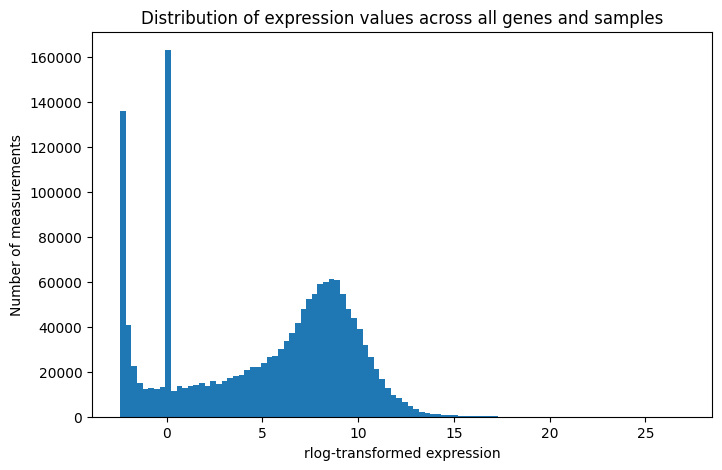

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    expression_values.to_numpy().ravel(),
    bins=100
)

plt.xlabel("rlog-transformed expression")
plt.ylabel("Number of measurements")
plt.title("Distribution of expression values across all genes and samples")

plt.show()

### Insight — Global expression distribution

#### The rlog-transformed expression matrix shows a heterogeneous, non-normal distribution across the 16,40,175 gene–sample measurements.

#### A pronounced accumulation occurs near the lower boundary of the transformed scale (~−2.42), together with a distinct spike at 0. 

#### The zero-valued component is fully explained by 2,657 genes that have a value of zero across all 57 samples. 

#### The main body of the distribution is concentrated at positive expression values, with a broad peak around 8–9 and a progressively decreasing right tail extending to a maximum of approximately >25. 

#### This indicates that the dataset contains a mixture of very low or uninformative features, moderately expressed genes, and a smaller number of highly expressed transcripts. 

#### The shape should not be interpreted as requiring normality, since genome-wide expression measurements naturally represent genes spanning very different abundance levels and biological functions. 

#### Because this plot pools all 57 samples, it characterizes the overall expression landscape but does not yet reveal whether individual samples or biological replicates have comparable distributions.

### Data Exploration Summary

#### Initial exploration established a structurally complete transcriptomic dataset containing 28,775 Arabidopsis gene features measured across 57 biological samples. The original unnamed feature column was confirmed to contain Arabidopsis gene identifiers and was harmonized to gene_id while preserving the original raw data artifact unchanged. All gene identifiers examined were consistent with the expected Arabidopsis identifier convention.

#### The 57 expression samples were successfully reconstructed into the experimental design. They comprise 27 endpoint samples, 27 recovery samples, and 3 controls, corresponding to nine abiotic stress conditions measured with three biological replicates in both endpoint and recovery states, plus three control replicates. Every experimental group contained the expected replicate set [1, 2, 3], giving 19 sample groups in total. The stress conditions were additionally decomposed into the underlying experimental factors—heat, drought, high light, cold, and high humidity—allowing single, double, and triple simultaneous stresses to be represented explicitly rather than only as categorical labels. The abbreviated T condition was harmonized to heat + drought + high light based on the study design and supplementary information.

#### The resulting sample manifest therefore preserves both the original matrix column names and a standardized biological representation containing experimental state, condition, replicate, individual stress factors, number of simultaneous stressors, stress-exposure status, and recovery duration. This provides a structured metadata layer linking every expression column to its biological context.

#### Numerical integrity checks showed that the expression matrix has the expected 28,775 × 57 dimensions, all 57 expression columns are numerical (float64), and there are no missing or infinite values. The matrix therefore contains all expected 1,640,175 gene–sample measurements.

#### Investigation of repeated numerical profiles showed that these should not be interpreted as duplicated biological genes. 2,657 genes are exactly zero across all 57 samples, accounting for all 151,449 zero-valued measurements in the matrix. Among the remaining genes, 1,241 genes participate in 172 distinct exact duplicate expression profiles. These profiles are overwhelmingly concentrated near the lower end of the transformed-expression scale, suggesting that they primarily represent very low-information expression patterns rather than duplicated gene records. Because the corresponding gene identifiers remain distinct, no genes were removed solely because their numerical profiles were identical.

#### Across the complete matrix, rlog-transformed expression values range from approximately −2.42 to 27.01, with a mean of approximately 5.06 and median of approximately 6.35. The global expression histogram reveals a pronounced low-expression component, a discrete zero component produced by the 2,657 all-zero genes, a broad main distribution of expressed genes, and a smaller high-expression tail. These values are interpreted as measurements on a transformed expression scale rather than literal transcript counts.

#### Overall, the exploratory phase found no obvious structural corruption, missing measurements, sample-count inconsistencies, or experimental-design inconsistencies. More importantly, the original semi-structured expression matrix has now been connected to a validated biological sample manifest. The dataset is therefore sufficiently understood to proceed to sample-level quality control, where individual sample distributions, biological-replicate consistency, sample correlations, clustering, PCA, and potential outliers will be evaluated before downstream biological analysis.